# CS1 EXP-2-IDABS — SVD(TF-IDF) + Static Features → MLP


## 1. Workspace root

In [1]:
from pathlib import Path

WORKSPACE_ROOT = Path.cwd()

print("WORKSPACE_ROOT:", WORKSPACE_ROOT)


WORKSPACE_ROOT: /workspace


## 2. Runtime switches

Run profile first. After the profile succeeds, disable profile and enable the official development CV.


In [2]:

RUN_PROFILE_FOLD = False

RUN_OFFICIAL_DEV_CV = True

LOAD_EXISTING_DEV_CV_ARTIFACTS = True

RUN_FINAL_OUTER_HOLDOUT = True

REQUIRE_GPU_FOR_OFFICIAL_RUN = True

REPO_URL = "https://github.com/EnomisLP/DiverseVul--IS-Project.git"
REPO_BRANCH = "simo"
INNER_N_SPLITS = 5
MODEL_RANDOM_STATE = 42

RUN_VERSION = "v2"

#CODE_COLUMN = "normalized_code"
CODE_COLUMN = "abstracted_code_v1"

CODE_COLUMN_TAG = "abstracted" if CODE_COLUMN == "abstracted_code_v1" else "normalized"

print("RUN_PROFILE_FOLD:", RUN_PROFILE_FOLD)
print("RUN_OFFICIAL_DEV_CV:", RUN_OFFICIAL_DEV_CV)
print("LOAD_EXISTING_DEV_CV_ARTIFACTS:", LOAD_EXISTING_DEV_CV_ARTIFACTS)
print("RUN_FINAL_OUTER_HOLDOUT:", RUN_FINAL_OUTER_HOLDOUT)
print("RUN_VERSION:", RUN_VERSION)


RUN_PROFILE_FOLD: False
RUN_OFFICIAL_DEV_CV: True
LOAD_EXISTING_DEV_CV_ARTIFACTS: True
RUN_FINAL_OUTER_HOLDOUT: True
RUN_VERSION: v2


## 3. Define paths


In [3]:
from pathlib import Path

DRIVE_ROOT = WORKSPACE_ROOT / "IntelligentSystemProject" / "VulnerabilityDetectionData"

PROCESSED_DIR = DRIVE_ROOT / "processed"
MANIFEST_ROOT = DRIVE_ROOT / "manifests"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"

EXPERIMENT_ID = "cs1_project_holdout20_innercv_v1"
EXPERIMENT_MANIFEST_DIR = MANIFEST_ROOT / EXPERIMENT_ID
EXPERIMENT_OUTPUT_DIR = OUTPUT_ROOT / EXPERIMENT_ID

OUTER_SPLIT_DIR = EXPERIMENT_MANIFEST_DIR / "outer_holdout"
INNER_SPLIT_DIR = EXPERIMENT_MANIFEST_DIR / "inner_cv"
STATIC_FEATURE_DIR = PROCESSED_DIR / "static_features"

NORMALIZED_DATA_PATH = PROCESSED_DIR / "rdiversevul_cs1_normalized_v1.parquet"
ABSTRACTED_DATA_PATH = PROCESSED_DIR / "rdiversevul_cs1_normalized_plus_abstracted_v2.parquet"
OUTER_MANIFEST_PATH = OUTER_SPLIT_DIR / "cs1_outer_project_holdout_manifest.parquet"
INNER_MANIFEST_PATH = INNER_SPLIT_DIR / "cs1_project_grouped_5fold_manifest.parquet"
INNER_SELECTION_METADATA_PATH = (
    INNER_SPLIT_DIR / "cs1_inner_grouped_split_selection_metadata.json"
)
STATIC_FEATURE_PATH = STATIC_FEATURE_DIR / "cs1_static_features_v1.parquet"

EXP2_IDABS_OUTPUT_DIR = EXPERIMENT_OUTPUT_DIR / f"exp2_mlp_idabs_dev_cv_{RUN_VERSION}_{CODE_COLUMN_TAG}"
EXP2_IDABS_PROFILE_DIR = EXP2_IDABS_OUTPUT_DIR / "profile_fold"

for directory in [
    PROCESSED_DIR,
    MANIFEST_ROOT,
    OUTPUT_ROOT,
    EXPERIMENT_MANIFEST_DIR,
    EXPERIMENT_OUTPUT_DIR,
    EXP2_IDABS_OUTPUT_DIR,
    EXP2_IDABS_PROFILE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Abstracted dataset:", ABSTRACTED_DATA_PATH)
print("Frozen outer manifest:", OUTER_MANIFEST_PATH)
print("Frozen inner manifest:", INNER_MANIFEST_PATH)
print("Static feature cache:", STATIC_FEATURE_PATH)
print("EXP-2-IDABS output:", EXP2_IDABS_OUTPUT_DIR)


Abstracted dataset: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/processed/rdiversevul_cs1_normalized_plus_abstracted_v2.parquet
Frozen outer manifest: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/manifests/cs1_project_holdout20_innercv_v1/outer_holdout/cs1_outer_project_holdout_manifest.parquet
Frozen inner manifest: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/manifests/cs1_project_holdout20_innercv_v1/inner_cv/cs1_project_grouped_5fold_manifest.parquet
Static feature cache: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/processed/static_features/cs1_static_features_v1.parquet
EXP-2-IDABS output: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp2_mlp_idabs_dev_cv_v2_abstracted


## 4. Clone or refresh the repository branch


In [4]:
from pathlib import Path
import sys

REPO_DIR = WORKSPACE_ROOT / "DiverseVul--IS-Project"
PROJECT_DIR = REPO_DIR / "vuln-detection"
SRC_DIR = PROJECT_DIR / "src"

import urllib.request
import zipfile


def download_and_extract_repo(repo_url, branch, target_dir):
    if target_dir.exists():
        print(f"Repository already exists at {target_dir}")
        return

    print(f"Downloading {repo_url} (branch: {branch}) without git...")
    clean_url = repo_url.removesuffix(".git")
    zip_url = f"{clean_url}/archive/refs/heads/{branch}.zip"
    target_dir.parent.mkdir(parents=True, exist_ok=True)
    zip_path = target_dir.parent / f"{target_dir.name}_download_temp.zip"

    urllib.request.urlretrieve(zip_url, zip_path)

    print("Extracting files...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(target_dir.parent)

    repo_name = clean_url.split("/")[-1]
    extracted_folder = target_dir.parent / f"{repo_name}-{branch}"
    if extracted_folder.exists():
        extracted_folder.rename(target_dir)

    zip_path.unlink()
    print(f"Repository ready at {target_dir}")

download_and_extract_repo(REPO_URL, REPO_BRANCH, REPO_DIR)

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Expected source directory does not exist: {SRC_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Repository:", REPO_DIR)
print("Source path:", SRC_DIR)


Repository already exists at /workspace/DiverseVul--IS-Project
Repository: /workspace/DiverseVul--IS-Project
Source path: /workspace/DiverseVul--IS-Project/vuln-detection/src


## 5. Verify required repository files


In [5]:
required_repo_files = [
    SRC_DIR / "case_study_1" / "evaluation.py",
    SRC_DIR / "case_study_1" / "split_manifest.py",
    SRC_DIR / "case_study_1" / "exp1" / "static_features.py",
    SRC_DIR / "case_study_1" / "exp2" / "__init__.py",
    SRC_DIR / "case_study_1" / "exp2" / "exp2_mlp.py",
]

missing_repo_files = [str(path) for path in required_repo_files if not path.exists()]
if missing_repo_files:
    raise FileNotFoundError(
        "Required EXP-2 files are missing:\n" + "\n".join(missing_repo_files)
    )

print("Required Case Study 1 files are present.")


Required Case Study 1 files are present.


## 6. Install dependencies


In [6]:
import sys
import subprocess

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "numpy",
        "pandas",
        "scipy",
        "scikit-learn",
        "matplotlib",
        "pyyaml",
        "pyarrow",
        "joblib",
    ],
    check=True,
)
print("Dependencies installed or already available.")


Dependencies installed or already available.


## 7. Import modules and check accelerator


In [7]:
import importlib
import json
import time

import numpy as np
import pandas as pd
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
from IPython.display import display

exp2_mlp = importlib.import_module("case_study_1.exp2.exp2_mlp")
static_features = importlib.import_module("case_study_1.exp1.static_features")
split_manifest = importlib.import_module("case_study_1.split_manifest")
evaluation = importlib.import_module("case_study_1.evaluation")

required_exp2_api = [
    "EXP2_VERSION",
    "Exp2Config",
    "run_exp2_profile_fold",
    "run_exp2",
]
missing_exp2_api = [name for name in required_exp2_api if not hasattr(exp2_mlp, name)]
if missing_exp2_api:
    raise AttributeError(f"EXP-2 runner is missing API: {missing_exp2_api}")

print("EXP-2 runner:", exp2_mlp.__file__)
print("EXP-2 version:", exp2_mlp.EXP2_VERSION)
print("Static feature module:", static_features.__file__)
print("Static feature count:", len(static_features.FEATURE_COLUMNS))
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory (GiB):",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
    )
else:
    print(
        "GPU is not active. Profile can still run on CPU if needed, but the official "
        "full MLP CV should use a GPU. In Colab: Runtime > Change runtime type > GPU."
    )


EXP-2 runner: /workspace/DiverseVul--IS-Project/vuln-detection/src/case_study_1/exp2/exp2_mlp.py
EXP-2 version: cs1-exp2-svd-static-mlp-v1-inner-val-holdout
Static feature module: /workspace/DiverseVul--IS-Project/vuln-detection/src/case_study_1/exp1/static_features.py
Static feature count: 54
PyTorch: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory (GiB): 79.15


## 8. Load abstracted dataset, frozen manifests, and static features


In [8]:
for required_path in [
    ABSTRACTED_DATA_PATH,
    OUTER_MANIFEST_PATH,
    INNER_MANIFEST_PATH,
    STATIC_FEATURE_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing frozen artifact: {required_path}\n"
            "Restore the completed preprocessing/split artifacts. Do not recreate "
            "split manifests in this notebook."
        )

full_df = pd.read_parquet(ABSTRACTED_DATA_PATH)
outer_manifest_df = pd.read_parquet(OUTER_MANIFEST_PATH)
inner_manifest_df = pd.read_parquet(INNER_MANIFEST_PATH)
static_df = pd.read_parquet(STATIC_FEATURE_PATH)

required_full_columns = {
    "source_row_id",
    "normalized_code",
    "abstracted_code_v1",
    "label",
    "project",
}
missing_full_columns = required_full_columns.difference(full_df.columns)
if missing_full_columns:
    raise KeyError(
        "Abstracted dataset is missing required columns:\n"
        f"{sorted(missing_full_columns)}\n\n"
        f"Available columns:\n{sorted(full_df.columns.tolist())}"
    )

required_outer_columns = {"source_row_id", "label", "project", "partition"}
missing_outer_columns = required_outer_columns.difference(outer_manifest_df.columns)
if missing_outer_columns:
    raise KeyError(f"Outer manifest missing columns: {sorted(missing_outer_columns)}")

selected_inner_split_seed = 42
if INNER_SELECTION_METADATA_PATH.exists():
    with INNER_SELECTION_METADATA_PATH.open("r", encoding="utf-8") as file:
        selected_inner_split_seed = int(
            json.load(file).get("selected_split_seed", 42)
        )

selected_inner_split_config = split_manifest.SplitConfig(
    n_splits=INNER_N_SPLITS,
    random_state=selected_inner_split_seed,
    shuffle=True,
)
split_manifest.assert_manifest_integrity(
    inner_manifest_df,
    config=selected_inner_split_config,
)

print("Loaded abstracted dataset:", ABSTRACTED_DATA_PATH)
print("Full dataset shape:", full_df.shape)
print("Outer manifest shape:", outer_manifest_df.shape)
print("Inner manifest shape:", inner_manifest_df.shape)
print("Static feature shape:", static_df.shape)
print("Selected inner split seed:", selected_inner_split_config.random_state)
print("Dataset columns:", sorted(full_df.columns.tolist()))
print("\nOuter partitions:")
print(outer_manifest_df["partition"].value_counts(dropna=False))


Loaded abstracted dataset: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/processed/rdiversevul_cs1_normalized_plus_abstracted_v2.parquet
Full dataset shape: (261667, 7)
Outer manifest shape: (261667, 5)
Inner manifest shape: (203958, 4)
Static feature shape: (261667, 55)
Selected inner split seed: 674
Dataset columns: ['abstracted_code_v1', 'abstracted_code_v1_scope2_failed', 'code', 'label', 'normalized_code', 'project', 'source_row_id']

Outer partitions:
partition
development      203958
outer_holdout     57709
Name: count, dtype: int64


## 9. Strict split and leakage validation


In [9]:
for name, frame in [
    ("full_df", full_df),
    ("outer_manifest_df", outer_manifest_df),
    ("inner_manifest_df", inner_manifest_df),
]:
    if frame["source_row_id"].duplicated().any():
        raise RuntimeError(f"{name} contains duplicate source_row_id values.")

full_indexed = full_df.set_index("source_row_id", drop=False).sort_index()

outer_ids = set(outer_manifest_df["source_row_id"].tolist())
dataset_ids = set(full_indexed.index.tolist())

if outer_ids != dataset_ids:
    raise RuntimeError(
        "Outer manifest IDs must exactly match the abstracted dataset.\n"
        f"Missing from dataset: {len(outer_ids - dataset_ids):,}\n"
        f"Extra in dataset: {len(dataset_ids - outer_ids):,}"
    )

outer_join = outer_manifest_df.set_index("source_row_id").join(
    full_indexed[["label", "project"]],
    rsuffix="_dataset",
)

if not (outer_join["label"].astype(int) == outer_join["label_dataset"].astype(int)).all():
    raise RuntimeError("Label mismatch between abstracted dataset and outer manifest.")

if not (
    outer_join["project"].astype(str).str.strip()
    == outer_join["project_dataset"].astype(str).str.strip()
).all():
    raise RuntimeError("Project mismatch between abstracted dataset and outer manifest.")

observed_partitions = set(outer_manifest_df["partition"].dropna().astype(str))
expected_partitions = {"development", "outer_holdout"}
if observed_partitions != expected_partitions:
    raise RuntimeError(
        f"Unexpected outer manifest partitions: {observed_partitions}. "
        f"Expected exactly: {expected_partitions}."
    )

dev_ids = set(
    outer_manifest_df.loc[
        outer_manifest_df["partition"] == "development",
        "source_row_id",
    ].tolist()
)
holdout_ids = set(
    outer_manifest_df.loc[
        outer_manifest_df["partition"] == "outer_holdout",
        "source_row_id",
    ].tolist()
)
inner_ids = set(inner_manifest_df["source_row_id"].tolist())

if not dev_ids or not holdout_ids:
    raise RuntimeError("Development or outer_holdout partition is empty.")

if dev_ids.intersection(holdout_ids):
    raise RuntimeError("Development and outer-holdout ID overlap detected.")

if inner_ids != dev_ids:
    raise RuntimeError(
        "Inner CV manifest IDs must exactly equal development IDs.\n"
        f"Missing from inner manifest: {len(dev_ids - inner_ids):,}\n"
        f"Extra in inner manifest: {len(inner_ids - dev_ids):,}"
    )

dev_projects = set(
    outer_manifest_df.loc[
        outer_manifest_df["partition"] == "development",
        "project",
    ].astype(str).str.strip()
)
holdout_projects = set(
    outer_manifest_df.loc[
        outer_manifest_df["partition"] == "outer_holdout",
        "project",
    ].astype(str).str.strip()
)
project_overlap = dev_projects.intersection(holdout_projects)
if project_overlap:
    raise RuntimeError(
        "Development/holdout project overlap detected: "
        f"{sorted(project_overlap)[:10]}"
    )

development_ids_sorted = sorted(dev_ids)
holdout_ids_sorted = sorted(holdout_ids)

dev_df = full_indexed.loc[development_ids_sorted].copy().reset_index(drop=True)
holdout_df = full_indexed.loc[holdout_ids_sorted].copy().reset_index(drop=True)

if set(dev_df["source_row_id"]).intersection(holdout_ids):
    raise RuntimeError("Outer-holdout rows leaked into dev_df.")

inner_fold_summary = split_manifest.summarize_manifest(
    inner_manifest_df,
    config=selected_inner_split_config,
)
if not (inner_fold_summary["train_test_project_overlap"] == 0).all():
    raise RuntimeError("At least one inner fold has train/test project overlap.")
if not (inner_fold_summary["test_vulnerable"] > 0).all():
    raise RuntimeError("At least one inner fold has zero vulnerable test samples.")
if not (inner_fold_summary["test_non_vulnerable"] > 0).all():
    raise RuntimeError("At least one inner fold has zero non-vulnerable test samples.")

summary_rows = []
for name, ids in [
    ("full_manifest", sorted(outer_ids)),
    ("development", development_ids_sorted),
    ("outer_holdout_locked", holdout_ids_sorted),
]:
    temp = full_indexed.loc[ids]
    summary_rows.append(
        {
            "partition": name,
            "rows": int(len(temp)),
            "projects": int(temp["project"].astype(str).nunique()),
            "vulnerable": int(temp["label"].astype(int).sum()),
            "positive_rate": float(temp["label"].astype(int).mean()),
        }
    )

split_summary_df = pd.DataFrame(summary_rows)
display(split_summary_df)

print("Frozen split validation passed.")
print("Development rows used by EXP-2-IDABS:", f"{len(dev_df):,}")
print("Global outer-holdout rows excluded from training/CV:", f"{len(holdout_df):,}")
print("\nInner development fold summary:")
display(inner_fold_summary)


,partition,rows,projects,vulnerable,positive_rate
0,full_manifest,261667,797,13938,0.053266
1,development,203958,594,10727,0.052594
2,outer_holdout_locked,57709,203,3211,0.055641


Frozen split validation passed.
Development rows used by EXP-2-IDABS: 203,958
Global outer-holdout rows excluded from training/CV: 57,709

Inner development fold summary:


,fold,test_rows,test_vulnerable,test_non_vulnerable,test_positive_rate,positive_rate_delta_from_global,test_unique_projects,train_rows,train_unique_projects,train_test_project_overlap,test_row_share,test_project_share
0,0,55509,2420,53089,0.043597,-0.008998,1,148449,593,0,0.272159,0.001684
1,1,40791,2091,38700,0.051261,-0.001333,158,163167,436,0,0.199997,0.265993
2,2,39072,2062,37010,0.052774,0.000180,146,164886,448,0,0.191569,0.245791
3,3,35016,2047,32969,0.058459,0.005865,137,168942,457,0,0.171682,0.230640
4,4,33570,2107,31463,0.062764,0.010170,152,170388,442,0,0.164593,0.255892


## 10. Empty-code guard and static-feature alignment


In [10]:
EMPTY_ABSTRACTED_SENTINEL = "EMPTY_ABSTRACTED_CODE_SAMPLE"

for frame_name, frame in [
    ("development", dev_df),
    ("outer_holdout_locked", holdout_df),
]:
    if CODE_COLUMN not in frame.columns:
        raise KeyError(
            f"{frame_name} frame is missing {CODE_COLUMN}.\n"
            f"Available columns: {sorted(frame.columns.tolist())}"
        )

    frame[CODE_COLUMN] = frame[CODE_COLUMN].fillna("").astype(str)
    empty_mask = frame[CODE_COLUMN].str.strip().eq("")
    n_empty = int(empty_mask.sum())
    print(f"Empty {CODE_COLUMN} rows in {frame_name}:", n_empty)

    if n_empty:
        frame.loc[empty_mask, CODE_COLUMN] = EMPTY_ABSTRACTED_SENTINEL
        print(
            f"Replaced {n_empty} empty rows in {frame_name} with "
            f"{EMPTY_ABSTRACTED_SENTINEL}"
        )

assert not dev_df[CODE_COLUMN].str.strip().eq("").any()
assert not holdout_df[CODE_COLUMN].str.strip().eq("").any()

expected_static_columns = [
    "source_row_id",
    *static_features.FEATURE_COLUMNS,
]
if list(static_df.columns) != expected_static_columns:
    raise ValueError(
        "Static-cache schema mismatch.\n"
        f"Expected: {expected_static_columns}\n"
        f"Actual: {list(static_df.columns)}"
    )

if static_df["source_row_id"].duplicated().any():
    raise ValueError("Static cache contains duplicate source_row_id values.")

static_indexed = static_df.set_index("source_row_id", drop=False).sort_index()
static_ids = set(static_indexed.index.tolist())

if not dev_ids.issubset(static_ids):
    raise ValueError("Static cache misses development IDs.")
if not holdout_ids.issubset(static_ids):
    raise ValueError("Static cache misses locked outer-holdout IDs.")

dev_static_df = static_indexed.loc[development_ids_sorted].copy().reset_index(drop=True)
holdout_static_df = static_indexed.loc[holdout_ids_sorted].copy().reset_index(drop=True)

if set(dev_static_df["source_row_id"]) != set(dev_df["source_row_id"]):
    raise RuntimeError("Development static features do not match dev_df IDs.")

print("Preprocessing guard passed.")
print("Development static feature rows:", f"{len(dev_static_df):,}")
print("Static features:", len(static_features.FEATURE_COLUMNS))


Empty abstracted_code_v1 rows in development: 1
Replaced 1 empty rows in development with EMPTY_ABSTRACTED_CODE_SAMPLE
Empty abstracted_code_v1 rows in outer_holdout_locked: 0
Preprocessing guard passed.
Development static feature rows: 203,958
Static features: 54


## 11. Configure EXP-2-IDABS MLP


In [11]:


from dataclasses import fields

supported_exp2_fields = {field.name for field in fields(exp2_mlp.Exp2Config)}

candidate_exp2_kwargs = {

    "experiment_name": "cs1_exp2_mlp_idabs_inner_dev_grouped",
    "code_column": CODE_COLUMN,
    "source_id_column": "source_row_id",
    "label_column": "label",
    "project_column": "project",
    "fold_column": "fold",
    "n_splits": INNER_N_SPLITS,
    "random_state": MODEL_RANDOM_STATE,
    "decision_threshold": 0.50,


    "word_ngram_range": (1, 3),
    "word_min_df": 3,
    "word_max_df": 0.995,
    "word_max_features": 50_000,
    "char_analyzer": "char",
    "char_ngram_range": (3, 4),
    "char_min_df": 8,
    "char_max_df": 0.995,
    "char_max_features": 60_000,
    "lowercase": False,
    "sublinear_tf": True,
    "tfidf_norm": "l2",


    "svd_n_components": 256,
    "svd_algorithm": "randomized",
    "svd_n_iter": 5,
    "svd_n_oversamples": 10,

    "hidden_dims": (128, 64),
    "hidden_layer_sizes": (128, 64),
    "hidden_units": (128, 64),
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 512,
    # The real Exp2Config field is split into batch_size_gpu / batch_size_cpu (not a
    # single "batch_size"), so "batch_size": 512 above was being silently dropped and
    # the run would fall back to the defaults (2048 GPU / 1024 CPU) instead of the
    # intended 512. Adding the real field names here so it actually takes effect.
    "batch_size_gpu": 512,
    "batch_size_cpu": 512,
    "max_epochs": 35,
    "epochs": 35,
    "patience": 4,
    "early_stopping_patience": 4,
    "validation_fraction": 0.15,
    "val_fraction": 0.15,
    "device": "cuda" if torch.cuda.is_available() else "cpu",


    "verbose": True,
}

exp2_kwargs = {
    key: value
    for key, value in candidate_exp2_kwargs.items()
    if key in supported_exp2_fields
}

ignored_exp2_kwargs = sorted(
    key for key in candidate_exp2_kwargs
    if key not in supported_exp2_fields
)

if "code_column" not in exp2_kwargs:
    raise RuntimeError(
        "Current exp2_mlp.Exp2Config does not expose code_column. "
        "Cannot run an IDABS representation experiment safely."
    )

exp2_config = exp2_mlp.Exp2Config(**exp2_kwargs)

def _config_value(config, names, default="not exposed by current Exp2Config"):
    for name in names:
        if hasattr(config, name):
            return getattr(config, name)
    return default

print("EXP-2-IDABS configuration")
print("=" * 80)
print("Experiment name:", exp2_config.experiment_name)
print("Input column:", exp2_config.code_column)
print("Word max features:", _config_value(exp2_config, ["word_max_features"]))
print("Char max features:", _config_value(exp2_config, ["char_max_features"]))
print("SVD components:", _config_value(exp2_config, ["svd_n_components"]))
print(
    "MLP hidden layers:",
    _config_value(
        exp2_config,
        ["hidden_dims", "hidden_layer_sizes", "hidden_units", "mlp_hidden_layer_sizes"],
    ),
)
print("Learning rate:", _config_value(exp2_config, ["learning_rate", "lr"]))
print("Batch size:", _config_value(exp2_config, ["batch_size"]))
print("Max epochs:", _config_value(exp2_config, ["max_epochs", "epochs"]))
print("Device:", _config_value(exp2_config, ["device"]))
print("Model random state:", MODEL_RANDOM_STATE)
print("Output directory:", EXP2_IDABS_OUTPUT_DIR)
print("Final outer holdout: locked and untouched")

print("\nAccepted Exp2Config fields used:")
print(sorted(exp2_kwargs.keys()))

print("\nCandidate settings ignored because this Exp2Config does not define them:")
print(ignored_exp2_kwargs)

print("\nAll supported Exp2Config fields in this repository:")
print(sorted(supported_exp2_fields))


EXP-2-IDABS configuration
Experiment name: cs1_exp2_mlp_idabs_inner_dev_grouped
Input column: abstracted_code_v1
Word max features: 50000
Char max features: 60000
SVD components: 256
MLP hidden layers: not exposed by current Exp2Config
Learning rate: 0.001
Batch size: not exposed by current Exp2Config
Max epochs: 35
Device: cuda
Model random state: 42
Output directory: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp2_mlp_idabs_dev_cv_v2_abstracted
Final outer holdout: locked and untouched

Accepted Exp2Config fields used:
['batch_size_cpu', 'batch_size_gpu', 'char_analyzer', 'char_max_df', 'char_max_features', 'char_min_df', 'char_ngram_range', 'code_column', 'decision_threshold', 'device', 'early_stopping_patience', 'experiment_name', 'fold_column', 'label_column', 'learning_rate', 'lowercase', 'max_epochs', 'n_splits', 'project_column', 'random_state', 'source_id_column', 'sublinear_tf', 'svd_algorithm', 'svd_n_components', 

## 12. Optional profile fold


In [12]:
PROFILE_FOLD_ID = int(
    inner_fold_summary.loc[
        inner_fold_summary["train_rows"].idxmax(),
        "fold",
    ]
)
profile_outer_train_rows = int(
    inner_fold_summary.loc[
        inner_fold_summary["fold"] == PROFILE_FOLD_ID,
        "train_rows",
    ].iloc[0]
)

print(
    "Selected profile fold:",
    f"Fold {PROFILE_FOLD_ID} with {profile_outer_train_rows:,} outer-train rows."
)

if RUN_PROFILE_FOLD:
    profile_start = time.perf_counter()
    exp2_profile_results = exp2_mlp.run_exp2_profile_fold(
        normalized_frame=dev_df,
        static_features_frame=dev_static_df,
        manifest=inner_manifest_df,
        fold_id=PROFILE_FOLD_ID,
        config=exp2_config,
    )
    profile_seconds = time.perf_counter() - profile_start

    print("\nProfile run completed in %.2f minutes." % (profile_seconds / 60.0))

    EXP2_IDABS_PROFILE_DIR.mkdir(parents=True, exist_ok=True)
    exp2_profile_results["predictions"].to_csv(
        EXP2_IDABS_PROFILE_DIR / "profile_fold_predictions.csv",
        index=False,
    )
    exp2_profile_results["training_history"].to_csv(
        EXP2_IDABS_PROFILE_DIR / "profile_training_history.csv",
        index=False,
    )
    exp2_profile_results["training_metadata"].to_csv(
        EXP2_IDABS_PROFILE_DIR / "profile_training_metadata.csv",
        index=False,
    )
    with (EXP2_IDABS_PROFILE_DIR / "profile_metrics.json").open("w", encoding="utf-8") as file:
        json.dump(exp2_profile_results["profile_metrics"], file, indent=2)
    with (EXP2_IDABS_PROFILE_DIR / "profile_validation_metrics.json").open("w", encoding="utf-8") as file:
        json.dump(exp2_profile_results["validation_metrics"], file, indent=2)
    with (EXP2_IDABS_PROFILE_DIR / "profile_default_threshold_metrics.json").open("w", encoding="utf-8") as file:
        json.dump(exp2_profile_results["default_threshold_metrics"], file, indent=2)

    print("Profile artifacts saved to:", EXP2_IDABS_PROFILE_DIR)
else:
    print("RUN_PROFILE_FOLD=False; profile skipped.")


Selected profile fold: Fold 4 with 170,388 outer-train rows.
RUN_PROFILE_FOLD=False; profile skipped.


## 13. Inspect profile result


In [13]:
import matplotlib.pyplot as plt

if "exp2_profile_results" not in globals():
    print("No profile result in memory. Run the profile cell first or skip this section.")
else:
    print("Largest-fold computational and training profile:")
    display(exp2_profile_results["training_metadata"])

    selected_threshold = float(
        exp2_profile_results["predictions"]["selected_validation_threshold"].iloc[0]
    )
    print("\nThreshold strategy: inner project-validation F1 selection.")
    print(f"Selected validation threshold: {selected_threshold:.3f}")

    print("\nInner-validation metrics used for threshold/checkpoint context:")
    display(
        pd.DataFrame(
            list(exp2_profile_results["validation_metrics"].items()),
            columns=["metric", "value"],
        )
    )

    print("\nOuter held-out profile-fold metrics — descriptive only, not official full CV:")
    display(
        pd.DataFrame(
            list(exp2_profile_results["profile_metrics"].items()),
            columns=["metric", "value"],
        )
    )

    print("\nFixed threshold = 0.50 diagnostic only:")
    display(
        pd.DataFrame(
            list(exp2_profile_results["default_threshold_metrics"].items()),
            columns=["metric", "value"],
        )
    )

    history_df = exp2_profile_results["training_history"].copy()
    print("\nEpoch-level training history:")
    display(history_df)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["validation_pr_auc"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Validation PR-AUC")
    plt.title("EXP-2-IDABS profile: validation PR-AUC by epoch")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_weighted_bce_loss"], label="train")
    plt.plot(history_df["epoch"], history_df["validation_weighted_bce_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Weighted BCE loss")
    plt.title("EXP-2-IDABS profile: weighted loss by epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()


No profile result in memory. Run the profile cell first or skip this section.


## 14. Official five-fold development CV


In [14]:
if RUN_OFFICIAL_DEV_CV:
    if REQUIRE_GPU_FOR_OFFICIAL_RUN and not torch.cuda.is_available():
        raise RuntimeError(
            "GPU is required for this official MLP run, but torch.cuda.is_available() "
            "is False. On Colab: Runtime > Change runtime type > GPU. On a local machine "
            "or remote VM: run `nvidia-smi` to confirm a GPU is attached, and check "
            "`torch.version.cuda` is not None (a CPU-only torch wheel reports None even "
            "with a GPU present -- reinstall a CUDA-enabled build if so). If no GPU is "
            "available and you accept a much slower CPU run, set "
            "REQUIRE_GPU_FOR_OFFICIAL_RUN = False in the runtime-switches cell above."
        )

    existing_files = [p for p in EXP2_IDABS_OUTPUT_DIR.iterdir() if p.name != "profile_fold"]
    if existing_files:
        raise RuntimeError(
            "EXP-2-IDABS official output directory already contains files.\n"
            f"Directory: {EXP2_IDABS_OUTPUT_DIR}\n"
            "Do not mix reruns. Change RUN_VERSION, for example RUN_VERSION='v2', "
            "and rerun the setup cells."
        )

    def _resolve_repo_commit(repo_root: Path, repo_branch: str) -> str:
        """Best-effort repo commit for provenance metadata.

        REPO_DIR was fetched as a zip archive (download_and_extract_repo), not a
        `git clone`, so there is no .git directory here -- `git rev-parse HEAD`
        would fail even if `git` were installed. Also handles `git` simply not
        being on PATH. Either way, fall back to a clearly labeled placeholder
        instead of crashing the run.
        """
        try:
            return subprocess.check_output(
                ["git", "-C", str(repo_root), "rev-parse", "HEAD"],
                stderr=subprocess.DEVNULL,
            ).decode().strip()
        except (FileNotFoundError, subprocess.CalledProcessError):
            return f"unknown (repo fetched via zip archive, branch={repo_branch}, no .git metadata)"

    repo_commit = _resolve_repo_commit(REPO_DIR, REPO_BRANCH)

    official_start = time.perf_counter()
    exp2_idabs_results = exp2_mlp.run_exp2(
        normalized_frame=dev_df,
        static_features_frame=dev_static_df,
        manifest=inner_manifest_df,
        config=exp2_config,
        output_dir=EXP2_IDABS_OUTPUT_DIR,
        additional_metadata={
            "run_kind": "exp2_identifier_abstraction_development_cv",
            "evaluation_stage": "inner_development_cv_only",
            "global_outer_holdout_used": False,
            "input_parquet": str(ABSTRACTED_DATA_PATH),
            "input_column": CODE_COLUMN,
            "outer_holdout_manifest_path": str(OUTER_MANIFEST_PATH),
            "inner_manifest_path": str(INNER_MANIFEST_PATH),
            "static_feature_cache_path": str(STATIC_FEATURE_PATH),
            "empty_abstracted_code_repair_token": EMPTY_ABSTRACTED_SENTINEL,
            "repo_commit": repo_commit,
            "note": (
                "Supplementary IDABS representation study. Development CV only; "
                "does not reopen final holdout model selection."
            ),
        },
    )
    official_seconds = time.perf_counter() - official_start
    print("\nOfficial EXP-2-IDABS development CV completed in %.2f minutes." % (official_seconds / 60.0))
    print("Artifacts saved to:", EXP2_IDABS_OUTPUT_DIR)
else:
    print("RUN_OFFICIAL_DEV_CV=False; official five-fold CV skipped.")


[13:33:15] CS1-EXP2 official run started: 5-fold grouped CV.
[13:33:15] Configuration: lexical<= 110,000, SVD=256, static=54, MLP=128->64->1, device=cuda.
[13:33:16] Fold 1/5 started | outer-train=148,449, outer-test=55,509, outer-train projects=593, outer-test projects=1.
[13:33:35] Fold 1/5 | inner project split: fit=118,745 rows / 472 projects; validation=29,704 rows / 121 projects.
[13:33:35] Fold 1/5 | fitting inner-train word TF-IDF...
[13:34:20] Fold 1/5 | word TF-IDF done in 44.6s (50,000 features).
[13:34:20] Fold 1/5 | fitting inner-train character TF-IDF...
[13:36:17] Fold 1/5 | character TF-IDF done in 1.95 min (60,000 features).
[13:36:17] Fold 1/5 | joining sparse lexical matrices...
[13:36:18] Fold 1/5 | fitting inner-train TruncatedSVD (256 components)...
[13:37:54] Fold 1/5 | TruncatedSVD done in 1.59 min (explained variance ratio sum=0.2650).
[13:37:54] Fold 1/5 | loading deterministic static features...
[13:37:54] Fold 1/5 | fitting inner-train StandardScaler...
[13:

## 15. Load existing official artifacts after restart


In [15]:


artifact_patterns = {
    "pooled_metrics": "*pooled_metrics.json",
    "validation_operating_pooled_metrics": "*validation*pooled_metrics.json",
    "fold_metrics": "*fold_metrics.csv",
    "fold_summary": "*fold_summary.csv",
    "fold_training": "*fold_training*.csv",
    "training_history": "*training_history*.csv",
    "oof_predictions": "*oof_predictions*.parquet",
}

loaded_exp2_idabs_artifacts = {}

if LOAD_EXISTING_DEV_CV_ARTIFACTS:
    print("Searching artifacts in:", EXP2_IDABS_OUTPUT_DIR)
    for key, pattern in artifact_patterns.items():
        matches = sorted(EXP2_IDABS_OUTPUT_DIR.glob(pattern))
        print(f"{key}: {[p.name for p in matches]}")


    json_candidates = sorted(EXP2_IDABS_OUTPUT_DIR.glob("*.json"))
    for path in json_candidates:
        name = path.name
        if "profile" in name:
            continue
        if "pooled_metrics" in name or "metrics" in name:
            try:
                with path.open("r", encoding="utf-8") as file:
                    loaded_exp2_idabs_artifacts[name] = json.load(file)
            except Exception as exc:
                print("Could not load JSON:", path, exc)

    # Load common CSV tables.
    for path in sorted(EXP2_IDABS_OUTPUT_DIR.glob("*.csv")):
        name = path.name
        if "profile" in name:
            continue
        try:
            loaded_exp2_idabs_artifacts[name] = pd.read_csv(path)
        except Exception as exc:
            print("Could not load CSV:", path, exc)

    print("Loaded artifact keys:", sorted(loaded_exp2_idabs_artifacts.keys()))
else:
    print("LOAD_EXISTING_DEV_CV_ARTIFACTS=False; artifact loading skipped.")


Searching artifacts in: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp2_mlp_idabs_dev_cv_v2_abstracted
pooled_metrics: ['cs1_exp2_mlp_idabs_inner_dev_grouped_pooled_metrics.json', 'cs1_exp2_mlp_idabs_inner_dev_grouped_validation_operating_pooled_metrics.json']
validation_operating_pooled_metrics: ['cs1_exp2_mlp_idabs_inner_dev_grouped_validation_operating_pooled_metrics.json']
fold_metrics: ['cs1_exp2_mlp_idabs_inner_dev_grouped_fold_metrics.csv', 'cs1_exp2_mlp_idabs_inner_dev_grouped_validation_operating_fold_metrics.csv']
fold_summary: ['cs1_exp2_mlp_idabs_inner_dev_grouped_fold_summary.csv', 'cs1_exp2_mlp_idabs_inner_dev_grouped_validation_operating_fold_summary.csv']
fold_training: ['cs1_exp2_mlp_idabs_inner_dev_grouped_fold_training.csv']
training_history: ['cs1_exp2_mlp_idabs_inner_dev_grouped_training_history.csv']
oof_predictions: ['cs1_exp2_mlp_idabs_inner_dev_grouped_oof_predictions.parquet']
Loaded artifact keys: [

## 16. Review official EXP-2-IDABS result


In [16]:
def _metrics_to_df(metrics, ordered_keys=None):
    if ordered_keys is None:
        ordered_keys = list(metrics.keys())
    return pd.DataFrame(
        [
            {"metric": key, "value": metrics.get(key)}
            for key in ordered_keys
            if key in metrics
        ]
    )

standard_evaluation = None
validation_operating = None
fold_training_df = None
training_history_df = None

if "exp2_idabs_results" in globals():
    standard_evaluation = exp2_idabs_results.get("evaluation")
    validation_operating = exp2_idabs_results.get("validation_operating_evaluation")
    fold_training_df = exp2_idabs_results.get("fold_training")
    training_history_df = exp2_idabs_results.get("training_history")
else:

    json_items = {
        key: value
        for key, value in loaded_exp2_idabs_artifacts.items()
        if isinstance(value, dict)
    }
    csv_items = {
        key: value
        for key, value in loaded_exp2_idabs_artifacts.items()
        if isinstance(value, pd.DataFrame)
    }


    pooled_candidates = [
        (name, data)
        for name, data in json_items.items()
        if "pooled_metrics" in name and "validation" not in name
    ]
    validation_candidates = [
        (name, data)
        for name, data in json_items.items()
        if "validation" in name and "pooled_metrics" in name
    ]

    if pooled_candidates:
        standard_evaluation = {"pooled_metrics": pooled_candidates[0][1]}
        print("Loaded standard pooled metrics from:", pooled_candidates[0][0])
    if validation_candidates:
        validation_operating = {"pooled_metrics": validation_candidates[0][1]}
        print("Loaded validation-operating metrics from:", validation_candidates[0][0])

    for name, df in csv_items.items():
        if "fold_training" in name:
            fold_training_df = df
        elif "training_history" in name:
            training_history_df = df

if standard_evaluation is None:
    print(
        "No official EXP-2-IDABS result found in memory or artifacts. "
        "Run Section 14 with RUN_OFFICIAL_DEV_CV=True."
    )
else:
    ranking_keys = [
        "n_samples",
        "vulnerable_1",
        "non_vulnerable_0",
        "positive_rate",
        "average_precision_pr_auc",
    ]
    print("EXP-2-IDABS pooled OOF ranking metrics — PR-AUC is primary:")
    display(_metrics_to_df(standard_evaluation["pooled_metrics"], ranking_keys))

    if validation_operating is not None:
        operating_keys = [
            "n_samples", "vulnerable_1", "non_vulnerable_0", "positive_rate",
            "average_precision_pr_auc", "precision", "recall", "f1", "mcc",
            "specificity", "false_positive_rate", "false_negative_rate",
            "true_negative", "false_positive", "false_negative", "true_positive",
            "predicted_positive", "predicted_positive_rate", "threshold_strategy",
            "selected_threshold_min", "selected_threshold_max", "selected_threshold_mean",
        ]
        print("\nEXP-2-IDABS pooled operating metrics — thresholds selected on inner validation only:")
        display(_metrics_to_df(validation_operating["pooled_metrics"], operating_keys))

    if fold_training_df is not None:
        print("\nFold-level preprocessing, training, and threshold information:")
        fold_columns = [
            "fold", "outer_train_rows", "outer_test_rows",
            "inner_fit_rows", "inner_validation_rows",
            "outer_train_unique_projects", "outer_test_unique_projects",
            "inner_fit_projects", "inner_validation_projects",
            "device", "final_dense_features", "best_epoch", "epochs_completed",
            "selected_validation_threshold", "validation_average_precision_pr_auc",
            "validation_f1", "mlp_training_seconds", "total_fold_seconds",
            "peak_gpu_memory_bytes",
        ]
        available_columns = [c for c in fold_columns if c in fold_training_df.columns]
        display(fold_training_df[available_columns])

    if training_history_df is not None:
        print("\nEpoch-level training history:")
        display(training_history_df)


EXP-2-IDABS pooled OOF ranking metrics — PR-AUC is primary:


,metric,value
0,n_samples,203958.000000
1,vulnerable_1,10727.000000
2,non_vulnerable_0,193231.000000
3,positive_rate,0.052594
4,average_precision_pr_auc,0.137688



EXP-2-IDABS pooled operating metrics — thresholds selected on inner validation only:


,metric,value
0,n_samples,203958
1,vulnerable_1,10727
2,non_vulnerable_0,193231
3,positive_rate,0.052594
4,average_precision_pr_auc,0.137688
5,precision,0.149195
6,recall,0.369908
7,f1,0.21263
8,mcc,0.167581
9,specificity,0.882897



Fold-level preprocessing, training, and threshold information:


,fold,outer_train_rows,outer_test_rows,inner_fit_rows,inner_validation_rows,outer_train_unique_projects,outer_test_unique_projects,inner_fit_projects,inner_validation_projects,device,final_dense_features,best_epoch,epochs_completed,selected_validation_threshold,validation_average_precision_pr_auc,validation_f1,mlp_training_seconds,total_fold_seconds,peak_gpu_memory_bytes
0,0,148449,55509,118745,29704,593,1,472,121,cuda,310,1,5,0.67,0.185025,0.266999,72.192278,358.805734,20678144
1,1,163167,40791,130587,32580,436,158,326,110,cuda,310,1,5,0.68,0.134693,0.216707,79.129746,378.914130,20122112
2,2,164886,39072,131895,32991,448,146,335,113,cuda,310,1,5,0.68,0.133577,0.199003,80.764809,374.404684,20476416
3,3,168942,35016,135151,33791,457,137,359,98,cuda,310,2,6,0.70,0.149938,0.237459,98.867038,400.810236,20705280
4,4,170388,33570,136295,34093,442,152,337,105,cuda,310,2,6,0.68,0.170978,0.262295,99.657958,394.650465,20216320



Epoch-level training history:


,fold,epoch,train_weighted_bce_loss,validation_weighted_bce_loss,validation_pr_auc,learning_rate,is_best_epoch
0,0,1,1.081401,1.342646,0.185025,0.001,True
1,0,2,0.984969,1.459297,0.175692,0.001,False
2,0,3,0.916148,1.381686,0.178736,0.001,False
3,0,4,0.841704,1.440742,0.177700,0.001,False
4,0,5,0.764589,1.653688,0.158193,0.001,False
5,1,1,1.100431,1.018612,0.134693,0.001,True
6,1,2,1.016371,1.021588,0.132978,0.001,False
7,1,3,0.950027,1.061218,0.121868,0.001,False
8,1,4,0.874938,1.100084,0.115466,0.001,False
9,1,5,0.800291,1.187277,0.116198,0.001,False


## 16b. Confidence interval on development-CV pooled PR-AUC

In [17]:
import case_study_1.confidence_intervals as confidence_intervals

exp2_idabs_devcv_ci = confidence_intervals.bootstrap_metric_ci(
    exp2_idabs_results["oof_predictions"],
    metric="average_precision_pr_auc",
    n_bootstrap=1000,
    random_state=42,
)
print(confidence_intervals.format_ci_report(exp2_idabs_devcv_ci))

average_precision_pr_auc: point estimate = 0.1377
  95% CI (project-block bootstrap): [0.1152, 0.1643]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  n_projects: 594, random_state=42
  Reflects sampling variability within this dataset only; not an estimate of generalization to C functions outside this collection.


## 17. Development-only comparison table


In [18]:
import pandas as pd

main_model_comparison = pd.DataFrame([
    {
        "experiment": "EXP-0 fixed LR",
        "representation": "normalized_code",
        "scope": "development pooled OOF",
        "pr_auc": 0.125205,
        "role": "original fixed baseline",
    },
    {
        "experiment": "EXP-1 RF",
        "representation": "SVD(TF-IDF normalized_code)+static",
        "scope": "development pooled OOF",
        "pr_auc": 0.124803,
        "role": "original fixed RF pipeline",
    },
    {
        "experiment": "EXP-2 MLP",
        "representation": "SVD(TF-IDF normalized_code)+static",
        "scope": "development pooled OOF",
        "pr_auc": 0.138157,
        "role": "selected original final model",
    },
]).sort_values("pr_auc", ascending=False)

exp0_tuning_comparison = pd.DataFrame([
    {
        "experiment": "EXP-0 fixed LR",
        "representation": "normalized_code",
        "scope": "development pooled OOF",
        "pr_auc": 0.125205,
        "role": "fixed baseline",
    },
    {
        "experiment": "EXP-0 nested-alpha LR",
        "representation": "normalized_code",
        "scope": "development nested pooled OOF",
        "pr_auc": 0.141971,
        "role": "supplementary tuned LR",
    },
    {
        "experiment": "EXP-0-IDABS nested-alpha LR",
        "representation": "abstracted_code_v1",
        "scope": "development nested pooled OOF",
        "pr_auc": 0.136888,
        "role": "supplementary tuned LR with IDABS",
    },
]).sort_values("pr_auc", ascending=False)

representation_comparison = pd.DataFrame([
    {
        "model_family": "EXP-0 nested-alpha LR",
        "normalized_pr_auc": 0.141971,
        "idabs_pr_auc": 0.136888,
        "delta_idabs_minus_normalized": 0.136888 - 0.141971,
    },
    {
        "model_family": "EXP-1 RF",
        "normalized_pr_auc": 0.124803,
        "idabs_pr_auc": 0.124013,
        "delta_idabs_minus_normalized": 0.124013 - 0.124803,
    },
    {
        "model_family": "EXP-2 MLP",
        "normalized_pr_auc": 0.138157,
        "idabs_pr_auc": 0.137544,
        "delta_idabs_minus_normalized": 0.137544 - 0.138157,
    },
])

display(main_model_comparison)
display(exp0_tuning_comparison)
display(representation_comparison)

,experiment,representation,scope,pr_auc,role
2,EXP-2 MLP,SVD(TF-IDF normalized_code)+static,development pooled OOF,0.138157,selected original final model
0,EXP-0 fixed LR,normalized_code,development pooled OOF,0.125205,original fixed baseline
1,EXP-1 RF,SVD(TF-IDF normalized_code)+static,development pooled OOF,0.124803,original fixed RF pipeline


,experiment,representation,scope,pr_auc,role
1,EXP-0 nested-alpha LR,normalized_code,development nested pooled OOF,0.141971,supplementary tuned LR
2,EXP-0-IDABS nested-alpha LR,abstracted_code_v1,development nested pooled OOF,0.136888,supplementary tuned LR with IDABS
0,EXP-0 fixed LR,normalized_code,development pooled OOF,0.125205,fixed baseline


,model_family,normalized_pr_auc,idabs_pr_auc,delta_idabs_minus_normalized
0,EXP-0 nested-alpha LR,0.141971,0.136888,-0.005083
1,EXP-1 RF,0.124803,0.124013,-0.000790
2,EXP-2 MLP,0.138157,0.137544,-0.000613


## 18. Canonical Retraining: Fit Optimal Model on Complete Development Set

In [19]:
if RUN_FINAL_OUTER_HOLDOUT:
    FINAL_HOLDOUT_OUTPUT_DIR = EXPERIMENT_OUTPUT_DIR / f"exp2_mlp_idabs_final_holdout_{RUN_VERSION}_{CODE_COLUMN_TAG}"
    FINAL_HOLDOUT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    exp2_idabs_final_holdout = exp2_mlp.run_exp2_final_holdout(
        dev_frame=dev_df,
        holdout_frame=holdout_df,
        static_features_frame=static_df,
        config=exp2_config,
        output_dir=FINAL_HOLDOUT_OUTPUT_DIR,
        additional_metadata={
            "run_kind": "exp2_idabs_final_outer_holdout",
            "input_column": CODE_COLUMN,
            "selection_source": "development_pooled_oof_pr_auc",
        },
    )
    print("Canonical retraining complete.")
    print("Artifacts saved to:", FINAL_HOLDOUT_OUTPUT_DIR)
else:
    exp2_idabs_final_holdout = None
    print("Final outer holdout remains locked. EXP-2-IDABS is development-only.")

[14:08:55] FINAL HOLDOUT | selecting epoch and threshold inside development only...
[14:09:19] FINAL HOLDOUT | fitting inner-train word TF-IDF...
[14:10:17] FINAL HOLDOUT | word TF-IDF done in 58.4s (50,000 features).
[14:10:17] FINAL HOLDOUT | fitting inner-train character TF-IDF...
[14:12:53] FINAL HOLDOUT | character TF-IDF done in 2.59 min (60,000 features).
[14:12:53] FINAL HOLDOUT | joining sparse lexical matrices...
[14:12:54] FINAL HOLDOUT | fitting inner-train TruncatedSVD (256 components)...
[14:14:54] FINAL HOLDOUT | TruncatedSVD done in 2.00 min (explained variance ratio sum=0.2590).
[14:15:15] Epoch 01/35 | train_loss=1.1212 | val_loss=1.3106 | val_PR-AUC=0.1532
[14:15:34] Epoch 02/35 | train_loss=1.0464 | val_loss=1.3282 | val_PR-AUC=0.1588
[14:15:54] Epoch 03/35 | train_loss=0.9839 | val_loss=1.4037 | val_PR-AUC=0.1367
[14:16:13] Epoch 04/35 | train_loss=0.9121 | val_loss=1.4811 | val_PR-AUC=0.1533
[14:16:33] Epoch 05/35 | train_loss=0.8351 | val_loss=1.5995 | val_PR-AUC

## 19. Final Evaluation: Score Frozen 20% Outer Holdout Partition

Pooled Out-of-Fold Evaluation
                   n_samples: 57709
                vulnerable_1: 3211
            non_vulnerable_0: 54498
               positive_rate: 0.055641
                   threshold: 0.660000
    average_precision_pr_auc: 0.139073
                   precision: 0.143160
                      recall: 0.378387
                          f1: 0.207728
                         mcc: 0.158538
                 specificity: 0.866564
         false_positive_rate: 0.133436
               true_negative: 47226
              false_positive: 7272
              false_negative: 1996
               true_positive: 1215


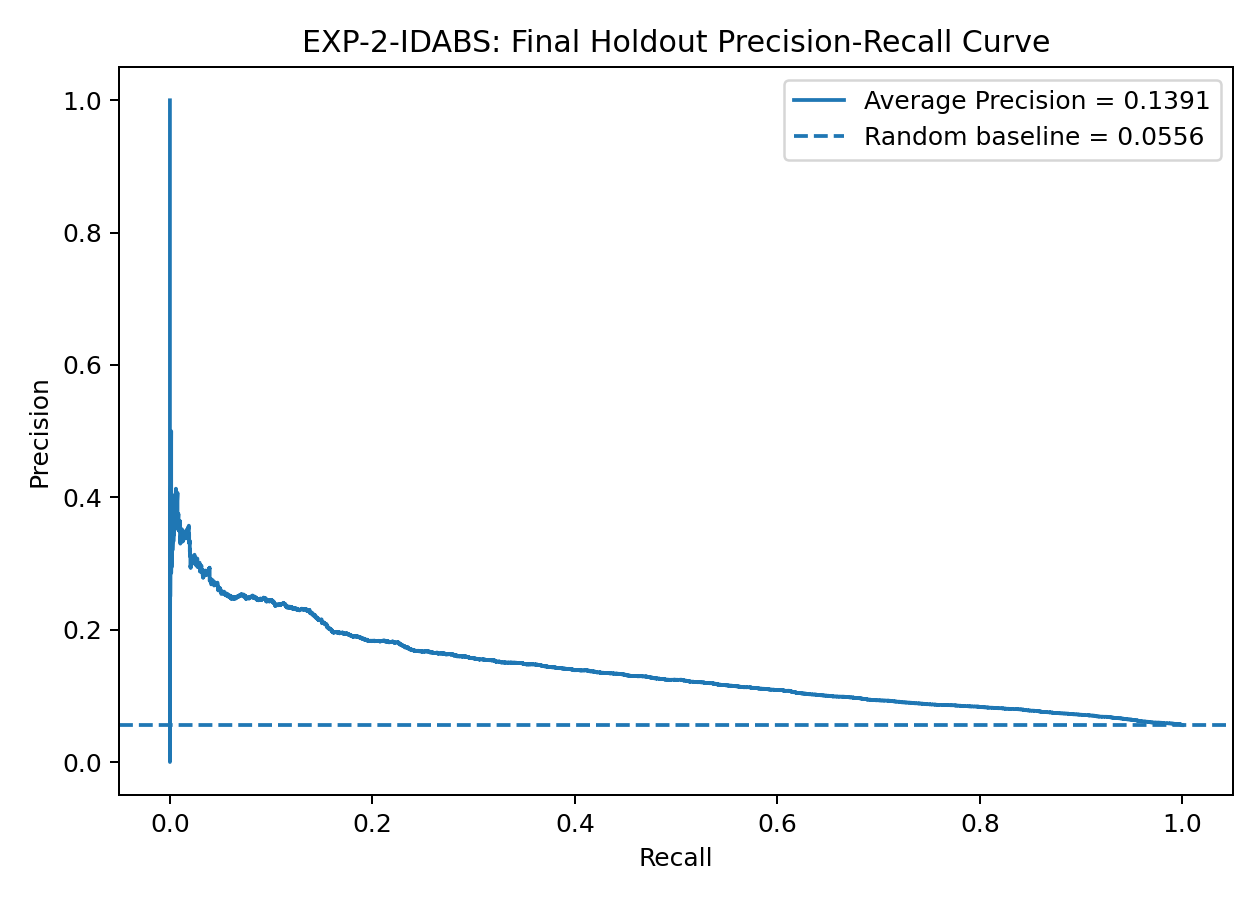

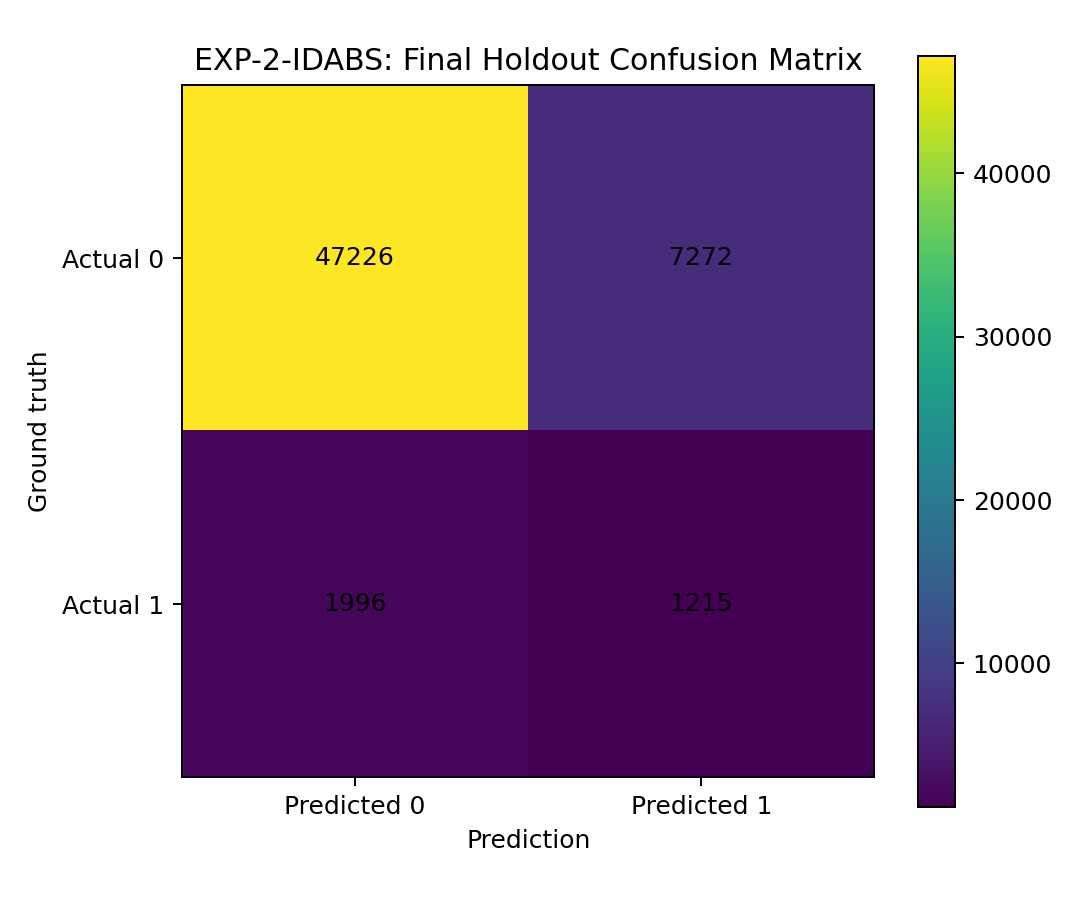

In [20]:
from IPython.display import Image

pr_curve_path = FINAL_HOLDOUT_OUTPUT_DIR / "exp2_idabs_holdout_precision_recall_curve.png"
cm_path = FINAL_HOLDOUT_OUTPUT_DIR / "exp2_idabs_holdout_confusion_matrix.png"

print(evaluation.format_metric_report(exp2_idabs_final_holdout["metrics"]))

evaluation.plot_precision_recall_curve(
    labels=exp2_idabs_final_holdout["predictions"]["label"],
    scores=exp2_idabs_final_holdout["predictions"]["y_score"],
    output_path=pr_curve_path,
    title="EXP-2-IDABS: Final Holdout Precision-Recall Curve",
)
evaluation.plot_confusion_matrix(
    labels=exp2_idabs_final_holdout["predictions"]["label"],
    predictions=exp2_idabs_final_holdout["predictions"]["y_pred"],
    output_path=cm_path,
    title="EXP-2-IDABS: Final Holdout Confusion Matrix",
)

display(Image(filename=str(pr_curve_path)))
display(Image(filename=str(cm_path)))

## 19b. Confidence interval on outer-holdout PR-AUC

In [21]:
import case_study_1.confidence_intervals as confidence_intervals

exp2_idabs_holdout_ci = confidence_intervals.bootstrap_metric_ci(
    exp2_idabs_final_holdout["predictions"],
    metric="average_precision_pr_auc",
    n_bootstrap=1000,
    random_state=42,
)
print(confidence_intervals.format_ci_report(exp2_idabs_holdout_ci))

average_precision_pr_auc: point estimate = 0.1391
  95% CI (project-block bootstrap): [0.1150, 0.1687]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  n_projects: 203, random_state=42
  Reflects sampling variability within this dataset only; not an estimate of generalization to C functions outside this collection.


## 20. Error Analysis: Isolate Holdout False Positives & False Negatives

In [22]:
holdout_errors = exp2_idabs_final_holdout["predictions"].merge(
    holdout_df[["source_row_id", CODE_COLUMN]],
    on="source_row_id",
    how="left",
)

false_positives = holdout_errors.loc[(holdout_errors["label"] == 0) & (holdout_errors["y_pred"] == 1)]
false_negatives = holdout_errors.loc[(holdout_errors["label"] == 1) & (holdout_errors["y_pred"] == 0)]

print(len(false_positives), len(false_negatives))
display(false_positives.sort_values("y_score", ascending=False).head(5))
display(false_negatives.sort_values("y_score", ascending=True).head(5))

7272 1996


,source_row_id,label,project,y_score,selected_validation_threshold,y_pred,abstracted_code_v1
27610,142295,0,php-src,0.998887,0.66,1,void FUNC0@TOKEN@(void)\n{\nstatic const opcod...
11165,53518,0,openjpeg,0.998193,0.66,1,"static int FUNC0@TOKEN@(int VAR0@TOKEN@, char ..."
4004,18614,0,MilkyTracker,0.996711,0.66,1,mp_sint32 LoaderXM::FUNC0@TOKEN@(XMFileBase& V...
9832,45858,0,cpython,0.991308,0.66,1,"FUNC0@TOKEN@(PyObject* VAR0@TOKEN@, stmt_ty* V..."
16423,76059,0,re2c,0.987129,0.66,1,InputBlockKind Scanner::FUNC0@TOKEN@(Output &V...


,source_row_id,label,project,y_score,selected_validation_threshold,y_pred,abstracted_code_v1
54523,247907,1,php-src,0.001244,0.66,0,static inline zend_string* FUNC0@TOKEN@(const ...
57029,258753,1,tip,0.009213,0.66,0,struct timerqueue_node *FUNC0@TOKEN@(struct ti...
57378,259825,1,envoy,0.018991,0.66,0,FUNC0@TOKEN@(const T* VAR0@TOKEN@) : value_(VA...
57375,259821,1,envoy,0.027155,0.66,0,uint64_t FUNC0@TOKEN@() const { return port_; }
57183,259216,1,envoy,0.028067,0.66,0,bool FUNC0@TOKEN@() override { return current_...


## 21. Final holdout report summary

In [23]:
holdout_report_summary = pd.DataFrame([{
    "experiment": "CS1-EXP2-IDABS-MLP",
    "representation": CODE_COLUMN,
    "dev_samples": len(dev_df),
    "holdout_samples": len(holdout_df),
    "pr_auc": exp2_idabs_final_holdout["metrics"]["average_precision_pr_auc"],
    "pr_auc_ci_low": exp2_idabs_holdout_ci.ci_low,
    "pr_auc_ci_high": exp2_idabs_holdout_ci.ci_high,
    "precision": exp2_idabs_final_holdout["metrics"]["precision"],
    "recall": exp2_idabs_final_holdout["metrics"]["recall"],
    "f1": exp2_idabs_final_holdout["metrics"]["f1"],
    "mcc": exp2_idabs_final_holdout["metrics"]["mcc"],
    "threshold": exp2_idabs_final_holdout["metrics"]["threshold"],
}])

holdout_report_summary.to_csv(
    FINAL_HOLDOUT_OUTPUT_DIR / "cs1_exp2_idabs_holdout_report_summary.csv",
    index=False,
)
display(holdout_report_summary)

,experiment,representation,dev_samples,holdout_samples,pr_auc,pr_auc_ci_low,pr_auc_ci_high,precision,recall,f1,mcc,threshold
0,CS1-EXP2-IDABS-MLP,abstracted_code_v1,203958,57709,0.139073,0.115003,0.168702,0.14316,0.378387,0.207728,0.158538,0.66
